# Sri Lanka VAM 2024 preprocessing with clear climate/admin merge

This notebook is deliberately strict and simple.

It does **three explicit merges/filters**:

1. Load household-level climate values from `lka_climate_24.csv`.
2. Load household-level ADM1/ADM2 names, codes, and geometries from `lka_24_hh_geo.csv`.
3. Inner-merge climate and geo by household id, then keep only rows with complete admin/geography/climate fields.
4. Process the VAM target variables.
5. Inner-merge targets with the complete household reference by household id, then keep only households with all required target/admin/climate variables.

No name-based fallback is used. If a household lacks a complete reference row, it is removed.


In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)

# ============================================================
# PATHS
# ============================================================

BASE_PROCESSING = Path("/data/shared/fsibilla/DATA_PROCESSING/lka_vam")
BASE_OUT = Path("/data/shared/fsibilla/DATA_PROCESSING/lka_vam")
BASE_OUT.mkdir(parents=True, exist_ok=True)

# Household-level climate values.
CLIMATE_HH_PATH = BASE_PROCESSING / "lka_climate_24.csv"

# Household-level ADM1/ADM2 names, codes, geometries.
HH_GEO_PATH = BASE_PROCESSING / "lka_24_hh_geo.csv"

# Original VAM target file used by the old notebook.
TARGET_XLSX_PATH = Path("/data/shared/fsibilla/wfp-da4hd/DATA/in/lka/data-fs-sp_final-v2.xlsx")

# Outputs.
CLIMATE_REF_PATH = BASE_PROCESSING / "climate_medians.csv"
HOUSEHOLD_REFERENCE_PATH = BASE_PROCESSING / "household_admin_climate_complete.csv"

FINAL_TARGETS_PATH = BASE_OUT / "vam_targets_with_climate.csv"
FINAL_FULL_PATH = BASE_OUT / "full.csv"

print("Climate household file:", CLIMATE_HH_PATH)
print("Household geo file:", HH_GEO_PATH)
print("Target Excel file:", TARGET_XLSX_PATH)
print("Climate reference output:", CLIMATE_REF_PATH)
print("Complete household reference output:", HOUSEHOLD_REFERENCE_PATH)
print("Final targets output:", FINAL_TARGETS_PATH)
print("Final full output:", FINAL_FULL_PATH)


Climate household file: /data/shared/fsibilla/DATA_PROCESSING/lka_vam/lka_climate_24.csv
Household geo file: /data/shared/fsibilla/DATA_PROCESSING/lka_vam/lka_24_hh_geo.csv
Target Excel file: /data/shared/fsibilla/wfp-da4hd/DATA/in/lka/data-fs-sp_final-v2.xlsx
Climate reference output: /data/shared/fsibilla/DATA_PROCESSING/lka_vam/climate_medians.csv
Complete household reference output: /data/shared/fsibilla/DATA_PROCESSING/lka_vam/household_admin_climate_complete.csv
Final targets output: /data/shared/fsibilla/DATA_PROCESSING/lka_vam/vam_targets_with_climate.csv
Final full output: /data/shared/fsibilla/DATA_PROCESSING/lka_vam/full.csv


## Helper functions

In [2]:
def clean_id_series(s: pd.Series) -> pd.Series:
    """
    Convert ids to clean strings.
    Handles Excel-style numeric ids such as 64979777.0 -> '64979777'.
    """
    out = s.astype(str).str.strip()
    out = out.str.replace(r"\.0$", "", regex=True)
    out = out.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return out


def clean_code_series(s: pd.Series) -> pd.Series:
    """
    Convert admin codes to clean strings.
    Handles float-like codes such as 2737.0 -> '2737'.
    Codes are kept as strings to avoid dtype problems with missing values.
    """
    out = s.astype(str).str.strip()
    out = out.str.replace(r"\.0$", "", regex=True)
    out = out.replace({"nan": np.nan, "None": np.nan, "": np.nan})
    return out


def safe_divide(num, den):
    """
    Returns num / den with:
      - den == 0 -> NaN
      - NaNs propagated
    """
    num = pd.to_numeric(num, errors="coerce")
    den = pd.to_numeric(den, errors="coerce")
    return num / den.replace({0: np.nan})


def safe_log(x):
    """
    log(x) with:
      - x <= 0 -> NaN
    """
    x = pd.to_numeric(x, errors="coerce")
    return np.where(x > 0, np.log(x), np.nan)


def require_cols(df: pd.DataFrame, cols, df_name="dataframe"):
    missing = [c for c in cols if c is None or c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in {df_name}: {missing}")


def first_existing(df: pd.DataFrame, candidates):
    """
    Return the first candidate column that exists in df, else None.
    """
    for c in candidates:
        if c in df.columns:
            return c
    return None


def report_missing(df: pd.DataFrame, cols, title="Missing values"):
    cols = [c for c in cols if c in df.columns]
    print(title)
    display(df[cols].isna().sum().to_frame("missing_count"))


## 1. Load household climate and household geo/admin files

`lka_climate_24.csv` has one row per household id with climate values.

`lka_24_hh_geo.csv` has one row per household id with ADM1/ADM2 names, codes, and geometries.

The merge key is the cleaned household id:

- climate: `Unnamed: 0`
- geo/admin: `@_id`


In [3]:
climate_hh_raw = pd.read_csv(CLIMATE_HH_PATH)
hh_geo_raw = pd.read_csv(HH_GEO_PATH)

print("climate_hh_raw shape:", climate_hh_raw.shape)
print("hh_geo_raw shape:", hh_geo_raw.shape)

print("\nClimate columns:")
print(list(climate_hh_raw.columns))

print("\nGeo/admin columns:")
print(list(hh_geo_raw.columns))

display(climate_hh_raw.head())
display(hh_geo_raw.head())


climate_hh_raw shape: (15100, 4)
hh_geo_raw shape: (15100, 8)

Climate columns:
['Unnamed: 0', 'r3q', 'rfh_avg', 'vim_avg']

Geo/admin columns:
['Unnamed: 0', '@_id', 'adm2Name', 'adm2Code', 'adm2Geometry', 'adm1Name', 'adm1Code', 'adm1Geometry']


,Unnamed: 0,r3q,rfh_avg,vim_avg
0,64979777,108.97085,30.5625,0.69295
1,64864373,108.97085,30.5625,0.69295
2,65572640,108.97085,30.5625,0.69295
3,65031840,108.97085,30.5625,0.69295
4,64977799,108.97085,30.5625,0.69295


,Unnamed: 0,@_id,adm2Name,adm2Code,adm2Geometry,adm1Name,adm1Code,adm1Geometry
0,0,64979777,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
1,1,64864373,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
2,2,65572640,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
3,3,65031840,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."
4,4,64977799,Ampara,25832.0,"POLYGON ((9043628.827892782 864076.9448993893,...",Eastern,2737.0,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612..."


## 2. Standardize climate and geo/admin columns

This cell only renames columns and cleans ids/codes. It does not merge yet.


In [4]:
# ----------------------------
# Climate household table
# ----------------------------
required_climate_raw_cols = ["Unnamed: 0", "r3q", "rfh_avg", "vim_avg"]
require_cols(climate_hh_raw, required_climate_raw_cols, "climate_hh_raw")

climate_hh = climate_hh_raw[required_climate_raw_cols].rename(
    columns={"Unnamed: 0": "id"}
).copy()

climate_hh["id"] = clean_id_series(climate_hh["id"])

climate_vars = ["r3q", "rfh_avg", "vim_avg"]
for c in climate_vars:
    climate_hh[c] = pd.to_numeric(climate_hh[c], errors="coerce")

# Keep only complete household climate rows.
before = len(climate_hh)
climate_hh = climate_hh.dropna(subset=["id"] + climate_vars).copy()
print("Climate rows before completeness filter:", before)
print("Climate rows after completeness filter:", len(climate_hh))
print("Dropped climate rows:", before - len(climate_hh))

# Remove duplicated climate ids if any, keeping the first complete row.
n_dup_climate = climate_hh["id"].duplicated().sum()
print("Duplicated climate household ids:", n_dup_climate)
if n_dup_climate > 0:
    climate_hh = climate_hh.drop_duplicates(subset=["id"], keep="first").copy()
    print("Climate rows after dropping duplicated ids:", len(climate_hh))


# ----------------------------
# Geo/admin household table
# ----------------------------
geo_rename = {
    "@_id": "id",
    "adm1Name": "adm1name",
    "adm1Code": "adm1code",
    "adm1Geometry": "adm1geometry",
    "adm2Name": "adm2name",
    "adm2Code": "adm2code",
    "adm2Geometry": "adm2geometry",
}

require_cols(hh_geo_raw, list(geo_rename.keys()), "hh_geo_raw")

hh_geo = hh_geo_raw[list(geo_rename.keys())].rename(columns=geo_rename).copy()

hh_geo["id"] = clean_id_series(hh_geo["id"])
hh_geo["adm1code"] = clean_code_series(hh_geo["adm1code"])
hh_geo["adm2code"] = clean_code_series(hh_geo["adm2code"])

for c in ["adm1name", "adm2name", "adm1geometry", "adm2geometry"]:
    hh_geo[c] = hh_geo[c].astype(str).str.strip()
    hh_geo[c] = hh_geo[c].replace({"nan": np.nan, "None": np.nan, "": np.nan})

required_geo_cols = [
    "id",
    "adm1name", "adm1code", "adm1geometry",
    "adm2name", "adm2code", "adm2geometry",
]

before = len(hh_geo)
hh_geo = hh_geo.dropna(subset=required_geo_cols).copy()
print("\nGeo/admin rows before completeness filter:", before)
print("Geo/admin rows after completeness filter:", len(hh_geo))
print("Dropped geo/admin rows:", before - len(hh_geo))

n_dup_geo = hh_geo["id"].duplicated().sum()
print("Duplicated geo household ids:", n_dup_geo)
if n_dup_geo > 0:
    hh_geo = hh_geo.drop_duplicates(subset=["id"], keep="first").copy()
    print("Geo/admin rows after dropping duplicated ids:", len(hh_geo))

print("\nClean climate_hh:")
display(climate_hh.head())

print("\nClean hh_geo:")
display(hh_geo.head())


Climate rows before completeness filter: 15100
Climate rows after completeness filter: 15100
Dropped climate rows: 0
Duplicated climate household ids: 0

Geo/admin rows before completeness filter: 15100
Geo/admin rows after completeness filter: 14744
Dropped geo/admin rows: 356
Duplicated geo household ids: 0

Clean climate_hh:


,id,r3q,rfh_avg,vim_avg
0,64979777,108.97085,30.5625,0.69295
1,64864373,108.97085,30.5625,0.69295
2,65572640,108.97085,30.5625,0.69295
3,65031840,108.97085,30.5625,0.69295
4,64977799,108.97085,30.5625,0.69295



Clean hh_geo:


,id,adm1name,adm1code,adm1geometry,adm2name,adm2code,adm2geometry
0,64979777,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,..."
1,64864373,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,..."
2,65572640,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,..."
3,65031840,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,..."
4,64977799,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,..."


## 3. Build the complete household admin + climate reference

This is the first important merge.

We merge:

```text
hh_geo[id, adm1/adm2 names/codes/geometries]
INNER JOIN
climate_hh[id, r3q, rfh_avg, vim_avg]
ON id
```

Because this is an **inner merge**, households missing from either file are removed.

Then we again drop rows missing any required reference column.


In [5]:
reference_required_cols = [
    "id",
    "adm1name", "adm1code", "adm1geometry",
    "adm2name", "adm2code", "adm2geometry",
    "r3q", "rfh_avg", "vim_avg",
]

household_reference = hh_geo.merge(
    climate_hh,
    on="id",
    how="inner",
    validate="one_to_one",
)

print("Rows in hh_geo:", len(hh_geo))
print("Rows in climate_hh:", len(climate_hh))
print("Rows after INNER household reference merge:", len(household_reference))

before = len(household_reference)
household_reference = (
    household_reference
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=reference_required_cols)
    .copy()
)
print("Rows after dropping incomplete household reference rows:", len(household_reference))
print("Dropped incomplete household reference rows:", before - len(household_reference))

report_missing(household_reference, reference_required_cols, "\nMissing values in household_reference required columns:")

household_reference.to_csv(HOUSEHOLD_REFERENCE_PATH, index=False)
print("\nSaved complete household reference to:")
print(HOUSEHOLD_REFERENCE_PATH)

display(household_reference.head())


Rows in hh_geo: 14744
Rows in climate_hh: 15100
Rows after INNER household reference merge: 14744
Rows after dropping incomplete household reference rows: 14744
Dropped incomplete household reference rows: 0

Missing values in household_reference required columns:


,missing_count
id,0
adm1name,0
adm1code,0
adm1geometry,0
adm2name,0
adm2code,0
adm2geometry,0
r3q,0
rfh_avg,0
vim_avg,0



Saved complete household reference to:
/data/shared/fsibilla/DATA_PROCESSING/lka_vam/household_admin_climate_complete.csv


,id,adm1name,adm1code,adm1geometry,adm2name,adm2code,adm2geometry,r3q,rfh_avg,vim_avg
0,64979777,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295
1,64864373,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295
2,65572640,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295
3,65031840,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295
4,64977799,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295


## 4. Build ADM1/ADM2 climate reference

This creates the same kind of `climate_medians.csv` used in the other preprocessing notebooks.

It is built only from the complete household reference created above.


In [6]:
# ADM2-level climate medians + canonical ADM1/ADM2 names, codes, geometries.
adm2_ref = (
    household_reference
    .groupby(["adm1code", "adm1name", "adm2code", "adm2name"], dropna=False)
    .agg(
        adm1geometry=("adm1geometry", "first"),
        adm2geometry=("adm2geometry", "first"),
        r3q_2=("r3q", "median"),
        rfh_avg_2=("rfh_avg", "median"),
        vim_avg_2=("vim_avg", "median"),
        n_hh_climate_2=("id", "size"),
    )
    .reset_index()
)

# ADM1-level climate medians.
adm1_ref = (
    household_reference
    .groupby(["adm1code", "adm1name"], dropna=False)
    .agg(
        r3q_1=("r3q", "median"),
        rfh_avg_1=("rfh_avg", "median"),
        vim_avg_1=("vim_avg", "median"),
        n_hh_climate_1=("id", "size"),
    )
    .reset_index()
)

# Add ADM1 medians to each ADM2 row.
climate_ref = adm2_ref.merge(
    adm1_ref[["adm1code", "r3q_1", "rfh_avg_1", "vim_avg_1", "n_hh_climate_1"]],
    on="adm1code",
    how="inner",
    validate="many_to_one",
)

climate_ref = climate_ref[
    [
        "adm1name", "adm1code", "adm1geometry",
        "adm2name", "adm2code", "adm2geometry",
        "r3q_1", "rfh_avg_1", "vim_avg_1",
        "r3q_2", "rfh_avg_2", "vim_avg_2",
        "n_hh_climate_1", "n_hh_climate_2",
    ]
].copy()

required_climate_ref_cols = list(climate_ref.columns)
before = len(climate_ref)
climate_ref = climate_ref.dropna(subset=required_climate_ref_cols).copy()
print("ADM2 climate reference rows before completeness filter:", before)
print("ADM2 climate reference rows after completeness filter:", len(climate_ref))

climate_ref.to_csv(CLIMATE_REF_PATH, index=False)
print("\nSaved ADM2 climate reference to:")
print(CLIMATE_REF_PATH)

display(climate_ref.head())


ADM2 climate reference rows before completeness filter: 25
ADM2 climate reference rows after completeness filter: 25

Saved ADM2 climate reference to:
/data/shared/fsibilla/DATA_PROCESSING/lka_vam/climate_medians.csv


,adm1name,adm1code,adm1geometry,adm2name,adm2code,adm2geometry,r3q_1,rfh_avg_1,vim_avg_1,r3q_2,rfh_avg_2,vim_avg_2,n_hh_climate_1,n_hh_climate_2
0,Central,2736,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",Matale,25830,"POLYGON ((9013984.447494535 836021.9841014954,...",104.50970,58.97725,0.77405,104.50970,48.32415,0.76940,1835,570
1,Central,2736,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",Kandy,41748,"POLYGON ((9013984.447494535 836021.9841014954,...",104.50970,58.97725,0.77405,108.28605,58.97725,0.78345,1835,668
2,Central,2736,"POLYGON ((80.9883 7.7204, 80.9851 7.7197, 80.9...",Nuwara Eliya,41749,"POLYGON ((9011179.196326545 803629.3846863932,...",104.50970,58.97725,0.77405,103.89535,72.19365,0.77405,1835,597
3,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",102.98975,24.52350,0.68325,108.97085,30.56250,0.69295,1748,601
4,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Batticaloa,25833,"POLYGON ((9056619.812468357 922453.2136869462,...",102.98975,24.52350,0.68325,102.98975,20.90995,0.60990,1748,549


## 5. Load VAM target data

This section mirrors the target-processing part of the old notebook.


In [7]:
df_raw = pd.read_excel(TARGET_XLSX_PATH)

print("Loaded target raw shape:", df_raw.shape)
print("Number of columns:", len(df_raw.columns))

display(df_raw.head())

COLUMN_NAMES_PATH = BASE_OUT / "lka_column_names.txt"
with open(COLUMN_NAMES_PATH, "w") as f:
    for col in df_raw.columns:
        f.write(str(col) + "\n")

print(f"Saved {len(df_raw.columns)} column names to:")
print(COLUMN_NAMES_PATH)


Loaded target raw shape: (15100, 512)
Number of columns: 512


,start,end,today,deviceid,TechnicalBasic_submoduleSvyDate,TechnicalBasic_submoduleSupvName,TechnicalBasic_submodulesupv_other,EnuName,enu_other,Province,Disitrict,DSDivison,GNDivison,OtherGNdivisonSpecifiy,sector,RESPConsent,resp_refusalwhy,resp_ref_other,EnuComments,resp_firstname,resp_lastname,RESPAge,RESPSex,RESPRelationHHH,RESPRelationHHH_oth,HHHAge,HHHSex,hh_education,hh_maritalstat,HHSize,HHSize01F,HHSize24F,HHSize511F,fem_hhmemHHSize1217F,fem_hhmemHHSize1859F,fem_hhmemHHSize59upF,male_hhmemHHSize01M,male_hhmemHHSize24M,male_hhmemHHSize511M,male_hhmemHHSize1217M,male_hhmemHHSize1859M,male_hhmemHHSize59upM,HHSize_calc,PMT_Education1,PMT_Education2,HHSizeRep,HHSizePlw,HHmem0_14,HHMem64above,HHmem1564,PMT_HHSizeCronDi,PMT_HHSizewhatcr,PMT_HHSizewhatcr1,PMT_HHSizewhatcr2,PMT_HHSizewhatcr3,PMT_HHSizewhatcr4,PMT_HHSizewhatcr5,PMT_HHSizewhatcr6,PMT_HHSizewhatcr7,PMT_HHSizewhatcr8,PMT_HHSizewhatcr9,PMT_HHSizewhatcr10,PMT_HHSizewhatcr999,PMT_HHSizewhatcr98,PMT_HHSizewhatcr99,HHSizewhatcrsp,note_dis,disability_walk,disability_seeing,disability_hearing,disability_remebre,disability_communica,disability_washing,disab_cal,dis_abo_5,dis_adul,hh_labor_7day,hh_work_status_7day,hh_type_work,hh_out_status,...,Hael_ass_38,Hael_ass_39,Hael_ass_4,UW_children,UW_children_number_female,UW_children_number_male,Aswasuma_allowance,Aswasuma_allowance_amount,Aswasuma_allowance_amount_oth,elderly_allowance,elderly_allowance_amount,disability_allowance,disability_allowance_amount,gov_benefit,gov_benefit_amount,Group_AAPHH_Decision,Call_end_1,Call_end_2,Call_end_3,Call_end_4,geo_point,@_geo_point_latitude,@_geo_point_longitude,@_geo_point_altitude,@_geo_point_precision,metainstanceID,@_id,@_uuid,@_submission_time,@_index,@_parent_table_name,@_parent_index,@_tags,@_notes,@_version,@_duration,@_submitted_by,@_xform_id,FCS,FCG,totalFexpweekly,TotalFexpMonthly,TotalNF1M,TotalNFexp6M,totalNFMonthly,foodexpshare,rCSI,FCS_4pt,stress_coping,crisis_coping,emergency_coping,Max_coping_behaviour,HHExp_Food_CRD_7D,HHExpFood_MN_7D,HHExp_Food_Own_7D,HHExp_Food_GiftAid_7D,HHExp_Food_Total_7D,HHExp_Food_Total_1M,non_food_Exp,HHExpNFTotal_6M,Total_HH_NF_EXP_1M,FES,Foodexp_4pt,Mean_coping_capacity_FES,CARI_unrounded_FES,CARI_FES,weight_GND,HHH_sex_final,rCSI_greater_than_0,rCSILessQlty_1,rCSIBorrow_1,rCSIMealSize_1,rCSIMealAdult_1,rCSIMealNb_1,Asbenallow,Allowance_clean,Allowance_numeric,CARI_Status,FCG_CAT,rCSI_categories
0,2024-12-09T12:18:45.199Z,2024-12-09T12:46:19.990Z,45635,collect:vpJZ7X9EYrPJyG1h,45635,Naveen Dharmawardhana- Ampara,NaN,R.M. Geethika Dissanayaka,NaN,Eastern,Ampara,Padiyathalawa,Pulungasmulla,NaN,Pradeshiya Sabha Area,Yes,NaN,NaN,NaN,Jinadasa,Herath Mudiyanselage,65,Male,Head of household,NaN,NaN,NaN,No schooling,Currently married (registered),7,0,0,0,0,2,1,1,0,0.0,1,1,1,7,1,0,1,1,1.0,2.0,4.0,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,0,NaN,NaN,Employed/working,Own-account worker,Temporary,NaN,...,NaN,NaN,NaN,No,NaN,NaN,Yes,Rs. 15000,NaN,Yes,3000.0,No,0.0,No,0.0,Both woman and man (husband and wife),Yes,743842941.0,NO,NaN,7.4916248 81.2796672 -24.796 1.87,7.491625,81.279667,-24.796,1.870000,uuid:4bd2a06c-96db-46bc-aab3-29f1073ad1c9,64979777,4bd2a06c-96db-46bc-aab3-29f1073ad1c9,2024-12-09 07:18:12,5471,NaN,-1,NaN,NaN,202411080652,1654,ipid_wfp,215004,49.0,3,9470.0,40910.4,28526.0,0.0,28526.0,0.589178,13,2,0,0,0,1,0.0,7290.0,2180.0,0.0,9470.0,41194.50,28526.0,0.0,28526.0,0.590852,2,1.5,1.75,2,0.616750,Male,1,1,0,1,0,1,Rs. 15000,15000,15000.0,0,1,2
1,2024-12-06T14:58:16.787Z,2024-12-06T18:34:54.065Z,45632,collect:vpJZ7X9EYrPJyG1h,45632,Naveen Dharmawardhana- Ampara,NaN,R.M. Geethika Dissanayaka,NaN,Eastern,Ampara,Ampara,Namalthalawa,NaN,Pradeshiya Sabha Area,Yes,NaN,NaN,NaN,Herath Banda,Herath Mudiyanselage,72,Male,Head of household,NaN,NaN,NaN,GCE (O/L) or equivalent,Currently married (registered),3,0,0,0,0,1,1,0,0,0.0,0,0,1,3,3,0,1,0,0.0,2.0,1.0,Yes,Blood pressure diabetes,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0

Saved 512 column names to:
/data/shared/fsibilla/DATA_PROCESSING/lka_vam/lka_column_names.txt


## 6. Compute derived target variables

The derived variables follow the old target notebook logic.


In [8]:
df = df_raw.copy()

# Education source columns.
col_edu1 = first_existing(df, ["HH_Education1", "PMT_Education1"])
col_edu2 = first_existing(df, ["HH_Education2", "PMT_Education2"])

# Adult members = 18–59 + 59up, female + male.
col_f18_59 = "fem_hhmemHHSize1859F"
col_f60_up = "fem_hhmemHHSize59upF"
col_m18_59 = "male_hhmemHHSize1859M"
col_m60_up = "male_hhmemHHSize59upM"

# Kid members = 5–11 + 12–17, female + male.
col_f5_11  = "HHSize511F"
col_f12_17 = "fem_hhmemHHSize1217F"
col_m5_11  = "male_hhmemHHSize511M"
col_m12_17 = "male_hhmemHHSize1217M"

col_income = first_existing(df, ["PMT_income_amt", "income_amt", "HH_income_amt"])
col_rooms  = first_existing(df, ["HRoomUsed", "rooms_used", "HH_rooms_used"])
col_hhsize = "HHSize"
col_hh_edu = "hh_education"

print("Using columns:")
print("Education1:", col_edu1)
print("Education2:", col_edu2)
print("Adult counts:", col_f18_59, col_f60_up, col_m18_59, col_m60_up)
print("Kid counts:", col_f5_11, col_f12_17, col_m5_11, col_m12_17)
print("Income:", col_income)
print("Rooms used:", col_rooms)
print("HH size:", col_hhsize)
print("HH head education:", col_hh_edu)

require_cols(df, [
    col_edu1, col_edu2,
    col_f18_59, col_f60_up, col_m18_59, col_m60_up,
    col_f5_11, col_f12_17, col_m5_11, col_m12_17,
    col_income, col_rooms, col_hhsize,
    col_hh_edu
], "target raw data")

adult_members = (
    pd.to_numeric(df[col_f18_59], errors="coerce") +
    pd.to_numeric(df[col_f60_up], errors="coerce") +
    pd.to_numeric(df[col_m18_59], errors="coerce") +
    pd.to_numeric(df[col_m60_up], errors="coerce")
)

kid_members = (
    pd.to_numeric(df[col_f5_11], errors="coerce") +
    pd.to_numeric(df[col_f12_17], errors="coerce") +
    pd.to_numeric(df[col_m5_11], errors="coerce") +
    pd.to_numeric(df[col_m12_17], errors="coerce")
)

edu1 = pd.to_numeric(df[col_edu1], errors="coerce")
edu2 = pd.to_numeric(df[col_edu2], errors="coerce")

E1_raw = safe_divide(edu1, adult_members)
E2_raw = 1.0 - safe_divide(edu2, kid_members)

# Neutralize undefined denominator cases to 0.5, as in the old logic.
E1 = np.where(
    (~np.isfinite(adult_members)) | (adult_members == 0) | (~np.isfinite(E1_raw)),
    0.5,
    E1_raw
)

E2 = np.where(
    (~np.isfinite(kid_members)) | (kid_members == 0) | (~np.isfinite(E2_raw)),
    0.5,
    E2_raw
)

education_score_base = 0.5 * (E1 + E2)

# Head-of-household education category mapping.
hh_edu_raw = df[col_hh_edu].astype(str).str.strip()

hh_edu_to_grade = {
    "No schooling": 0,
    "Grade 1": 1,
    "Grade 2": 2,
    "Grade 3": 3,
    "Grade 4": 4,
    "Grade 5": 5,
    "Grade 6": 6,
    "Grade 7": 7,
    "Grade 8": 8,
    "Grade 9": 9,
    "Grade 10": 10,
    "GCE (O/L) or equivalent": 11,
    "Grade 12": 12,
    "GCE (A/L) or equivalent": 13,
    "Passed Degree": 16,
    "Passed Post-graduate degree/diploma": 18,
    "PHD": 21,
    "Don't know": np.nan,
    "Refuse to answer": np.nan,
    "GAQ/GSQ": np.nan,
    "Special education/training": np.nan,
}

hh_grade = hh_edu_raw.map(hh_edu_to_grade).astype(float)
head_score = np.clip(hh_grade / 21.0, 0, 1)

education_score = np.where(
    np.isfinite(head_score),
    0.5 * education_score_base + 0.5 * head_score,
    education_score_base
)

df["education_score"] = np.clip(education_score, 0, 1)
df["log_income"] = safe_log(df[col_income])
df["space_per_person"] = safe_divide(df[col_rooms], df[col_hhsize])

print("\nHH head education category counts:")
display(hh_edu_raw.value_counts(dropna=False).head(30))

print("\nDerived variable summary:")
display(df[["education_score", "log_income", "space_per_person"]].describe())


Using columns:
Education1: PMT_Education1
Education2: PMT_Education2
Adult counts: fem_hhmemHHSize1859F fem_hhmemHHSize59upF male_hhmemHHSize1859M male_hhmemHHSize59upM
Kid counts: HHSize511F fem_hhmemHHSize1217F male_hhmemHHSize511M male_hhmemHHSize1217M
Income: PMT_income_amt
Rooms used: HRoomUsed
HH size: HHSize
HH head education: hh_education

HH head education category counts:


hh_education
GCE (O/L) or equivalent                4953
Grade 10                               1599
Grade 8                                1563
GCE (A/L) or equivalent                1516
Grade 5                                1323
Grade 9                                 699
Grade 6                                 566
Grade 7                                 559
No schooling                            438
Grade 3                                 434
Grade 4                                 428
Grade 2                                 350
Grade 12                                219
Passed Degree                           217
Grade 1                                  99
Passed Post-graduate degree/diploma      62
Don't know                               41
GAQ/GSQ                                  17
Refuse to answer                          7
Special education/training                5
PHD                                       5
Name: count, dtype: int64


Derived variable summary:


,education_score,log_income,space_per_person
count,15100.000000,14785.000000,15100.000000
mean,0.545427,11.483776,0.866159
std,0.187595,0.665282,0.620949
min,0.000000,9.210340,0.000000
25%,0.398810,11.002100,0.500000
50%,0.565476,11.407565,0.750000
75%,0.684524,11.918391,1.000000
max,1.000000,14.914123,6.000000


## 7. Keep target columns and required survey identifiers

This cell creates `df_keep`, the target table to be merged with the complete household reference.

Rows missing any required target/survey field are removed here.


In [9]:
# Identify core survey columns robustly.
col_id = first_existing(df, ["@_id", "id", "hh_id"])
col_adm1_survey = first_existing(df, ["Province", "adm1name", "adm1Name"])
col_adm2_survey = first_existing(df, ["District", "Disitrict", "adm2name", "adm2Name"])
col_sector = first_existing(df, ["sector", "Sector"])
col_psu = first_existing(df, ["GNDivison", "GNDivision", "GN_Division", "psu"])

target_cols = ["education_score", "log_income", "space_per_person", "FES", "FCS", "rCSI"]

print("Using id column:", col_id)
print("Using survey ADM1 column:", col_adm1_survey)
print("Using survey ADM2 column:", col_adm2_survey)
print("Using sector column:", col_sector)
print("Using PSU column:", col_psu)
print("Using target columns:", target_cols)

require_cols(df, [col_id, col_adm1_survey, col_adm2_survey, col_sector, col_psu] + target_cols, "target data")

df_keep = df[target_cols + [col_id, col_adm1_survey, col_adm2_survey, col_sector, col_psu]].copy()

df_keep = df_keep.rename(columns={
    col_id: "id",
    col_adm1_survey: "survey_adm1name",
    col_adm2_survey: "survey_adm2name",
    col_sector: "sector",
    col_psu: "psu",
})

df_keep["id"] = clean_id_series(df_keep["id"])

required_target_cols = [
    "id",
    "education_score", "log_income", "space_per_person",
    "FES", "FCS", "rCSI",
    "survey_adm1name", "survey_adm2name",
    "sector", "psu",
]

df_keep = df_keep.replace([np.inf, -np.inf], np.nan)

print("Rows before target completeness filter:", len(df_keep))
report_missing(df_keep, required_target_cols, "\nMissing values before target completeness filter:")

before = len(df_keep)
df_keep = df_keep.dropna(subset=required_target_cols).copy()
print("\nRows after target completeness filter:", len(df_keep))
print("Dropped target rows:", before - len(df_keep))

# Duplicated ids would break one-to-one household merge.
n_dup_targets = df_keep["id"].duplicated().sum()
print("Duplicated target household ids:", n_dup_targets)
if n_dup_targets > 0:
    display(df_keep[df_keep["id"].duplicated(keep=False)].sort_values("id").head(50))
    raise ValueError("Target household ids are duplicated. Please resolve before merging.")

display(df_keep.head())


Using id column: @_id
Using survey ADM1 column: Province
Using survey ADM2 column: Disitrict
Using sector column: sector
Using PSU column: GNDivison
Using target columns: ['education_score', 'log_income', 'space_per_person', 'FES', 'FCS', 'rCSI']


Rows before target completeness filter: 15100

Missing values before target completeness filter:


,missing_count
id,0
education_score,0
log_income,315
space_per_person,0
FES,0
FCS,0
rCSI,0
survey_adm1name,0
survey_adm2name,0
sector,0



Rows after target completeness filter: 14785
Dropped target rows: 315
Duplicated target household ids: 0


,education_score,log_income,space_per_person,FES,FCS,rCSI,id,survey_adm1name,survey_adm2name,sector,psu
0,0.300000,11.082143,0.285714,0.590852,49.0,13,64979777,Eastern,Ampara,Pradeshiya Sabha Area,Pulungasmulla
1,0.636905,11.918391,1.333333,0.644397,83.0,0,64864373,Eastern,Ampara,Pradeshiya Sabha Area,Namalthalawa
2,0.511905,10.714418,0.000000,0.377111,59.0,19,65572640,Eastern,Ampara,Pradeshiya Sabha Area,Karaitheevu 01
3,0.988095,11.082143,0.500000,0.545401,40.0,7,65031840,Eastern,Ampara,Pradeshiya Sabha Area,Poolawala
4,0.235119,11.695247,0.750000,0.524437,57.0,21,64977799,Eastern,Ampara,Pradeshiya Sabha Area,Pulungasmulla


## 8. Encode sector

The original sector value is preserved in `sector_original`.

The model-friendly numeric version is stored in `sector`.


In [10]:
df_keep["sector_original"] = df_keep["sector"].astype(str).str.strip()

sector_mapping = {s: i + 1 for i, s in enumerate(df_keep["sector_original"].dropna().unique())}
df_keep["sector"] = df_keep["sector_original"].map(sector_mapping)

n_sector_missing = df_keep["sector"].isna().sum()

print("Unique sectors:", len(sector_mapping))
print("NaNs after sector mapping:", n_sector_missing)

if n_sector_missing > 0:
    display(df_keep.loc[df_keep["sector"].isna(), ["sector_original"]].head(20))
    raise ValueError("Some sector values could not be encoded.")

print("Sector mapping:")
for k, v in sector_mapping.items():
    print(f"{k!r} -> {v}")


Unique sectors: 3
NaNs after sector mapping: 0
Sector mapping:
'Pradeshiya Sabha Area' -> 1
'Municipal / Urban Council Area' -> 2
'Estate Management' -> 3


## 9. Merge targets with complete household reference

This is the second important merge.

We merge:

```text
df_keep[target variables + survey identifiers]
INNER JOIN
household_reference[complete ADM1/ADM2 + household climate]
ON id
```

Because this is an **inner merge**, final rows are kept only if the household exists in both the target data and the complete household reference.

Then we attach ADM1/ADM2 median climate variables using ADM codes.


In [11]:
# First, merge target rows with complete household admin + climate values.
reference_cols_for_final = [
    "id",
    "adm1name", "adm1code", "adm1geometry",
    "adm2name", "adm2code", "adm2geometry",
    "r3q", "rfh_avg", "vim_avg",
]

df_final = df_keep.merge(
    household_reference[reference_cols_for_final],
    on="id",
    how="inner",
    validate="one_to_one",
)

print("Rows in complete target table before reference merge:", len(df_keep))
print("Rows in complete household reference:", len(household_reference))
print("Rows after INNER target-reference merge:", len(df_final))
print("Target rows removed because they lack complete household reference:", len(df_keep) - len(df_final))

# Attach ADM1/ADM2 climate medians using canonical ADM codes.
climate_for_merge = climate_ref[
    [
        "adm1code", "adm2code",
        "r3q_1", "rfh_avg_1", "vim_avg_1",
        "r3q_2", "rfh_avg_2", "vim_avg_2",
        "n_hh_climate_1", "n_hh_climate_2",
    ]
].copy()

df_final = df_final.merge(
    climate_for_merge,
    on=["adm1code", "adm2code"],
    how="inner",
    validate="many_to_one",
)

print("\nRows after attaching ADM1/ADM2 climate medians:", len(df_final))

required_final_cols = [
    "id",
    "education_score", "log_income", "space_per_person", "FES", "FCS", "rCSI",
    "sector", "sector_original", "psu",
    "survey_adm1name", "survey_adm2name",
    "adm1name", "adm1code", "adm1geometry",
    "adm2name", "adm2code", "adm2geometry",
    "r3q", "rfh_avg", "vim_avg",
    "r3q_1", "rfh_avg_1", "vim_avg_1",
    "r3q_2", "rfh_avg_2", "vim_avg_2",
]

df_final = df_final.replace([np.inf, -np.inf], np.nan)

print("\nMissing values before final completeness filter:")
display(df_final[required_final_cols].isna().sum().to_frame("missing_count"))

before = len(df_final)
df_final = df_final.dropna(subset=required_final_cols).copy()
print("\nRows after final completeness filter:", len(df_final))
print("Dropped rows at final completeness filter:", before - len(df_final))

# Final safety checks.
if df_final["id"].duplicated().any():
    raise ValueError("Final dataset has duplicated household ids.")

report_missing(df_final, required_final_cols, "\nFinal missing values in required columns:")

display(df_final.head())


Rows in complete target table before reference merge: 14785
Rows in complete household reference: 14744
Rows after INNER target-reference merge: 14488
Target rows removed because they lack complete household reference: 297

Rows after attaching ADM1/ADM2 climate medians: 14488

Missing values before final completeness filter:


,missing_count
id,0
education_score,0
log_income,0
space_per_person,0
FES,0
FCS,0
rCSI,0
sector,0
sector_original,0
psu,0



Rows after final completeness filter: 14488
Dropped rows at final completeness filter: 0

Final missing values in required columns:


,missing_count
id,0
education_score,0
log_income,0
space_per_person,0
FES,0
FCS,0
rCSI,0
sector,0
sector_original,0
psu,0


,education_score,log_income,space_per_person,FES,FCS,rCSI,id,survey_adm1name,survey_adm2name,sector,psu,sector_original,adm1name,adm1code,adm1geometry,adm2name,adm2code,adm2geometry,r3q,rfh_avg,vim_avg,r3q_1,rfh_avg_1,vim_avg_1,r3q_2,rfh_avg_2,vim_avg_2,n_hh_climate_1,n_hh_climate_2
0,0.300000,11.082143,0.285714,0.590852,49.0,13,64979777,Eastern,Ampara,1,Pulungasmulla,Pradeshiya Sabha Area,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601
1,0.636905,11.918391,1.333333,0.644397,83.0,0,64864373,Eastern,Ampara,1,Namalthalawa,Pradeshiya Sabha Area,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601
2,0.511905,10.714418,0.000000,0.377111,59.0,19,65572640,Eastern,Ampara,1,Karaitheevu 01,Pradeshiya Sabha Area,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601
3,0.988095,11.082143,0.500000,0.545401,40.0,7,65031840,Eastern,Ampara,1,Poolawala,Pradeshiya Sabha Area,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601
4,0.235119,11.695247,0.750000,0.524437,57.0,21,64977799,Eastern,Ampara,1,Pulungasmulla,Pradeshiya Sabha Area,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601


In [14]:
# ============================================================
# Add entropy and RWI admin-level averages
# Run this after df_final has been created and before saving.
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely import wkt
from shapely.geometry import Point
from pathlib import Path

ENTROPY_TIF_PATH = Path("/data/shared/fsibilla/wfp-da4hd/DATA/in/lka/entropy_mod_4h_moto.tif")
RWI_CSV_PATH = Path("/data/shared/fsibilla/wfp-da4hd/DATA/in/lka/lka_relative_wealth_index.csv")

print("Entropy raster:", ENTROPY_TIF_PATH)
print("RWI CSV:", RWI_CSV_PATH)


def geometry_series_to_gdf(df, geometry_col, crs=None):
    """
    Convert a dataframe with WKT geometries into a GeoDataFrame.
    If crs is not provided, infer EPSG:4326 vs EPSG:3857 from bounds.
    """
    out = df.copy()

    out[geometry_col] = out[geometry_col].apply(
        lambda x: wkt.loads(x) if isinstance(x, str) else x
    )

    gdf = gpd.GeoDataFrame(out, geometry=geometry_col)

    if crs is None:
        bounds = gdf.total_bounds  # minx, miny, maxx, maxy

        # If coordinates look like lon/lat, use EPSG:4326.
        # If they are large projected coordinates, use EPSG:3857.
        if (
            -180 <= bounds[0] <= 180
            and -90 <= bounds[1] <= 90
            and -180 <= bounds[2] <= 180
            and -90 <= bounds[3] <= 90
        ):
            crs = "EPSG:4326"
        else:
            crs = "EPSG:3857"

    gdf = gdf.set_crs(crs, allow_override=True)
    return gdf


def zonal_mean_from_raster(gdf, value_name, raster_path):
    """
    Compute mean raster value inside each geometry.
    """
    results = []

    with rasterio.open(raster_path) as src:
        raster_crs = src.crs

        gdf_raster = gdf.to_crs(raster_crs)

        for _, row in gdf_raster.iterrows():
            geom = row.geometry

            try:
                out_image, _ = mask(src, [geom], crop=True, filled=False)
                arr = out_image[0]

                if np.ma.isMaskedArray(arr):
                    vals = arr.compressed()
                else:
                    vals = arr.reshape(-1)

                vals = vals[np.isfinite(vals)]

                if src.nodata is not None:
                    vals = vals[vals != src.nodata]

                mean_val = float(np.mean(vals)) if len(vals) > 0 else np.nan

            except Exception:
                mean_val = np.nan

            results.append(mean_val)

    out = gdf.drop(columns="geometry", errors="ignore").copy()
    out[value_name] = results
    return out


def add_rwi_mean_by_admin(admin_gdf, admin_code_col, admin_name_col, rwi_path, value_name):
    """
    Spatially join RWI point data to admin polygons and compute mean RWI.
    """
    rwi = pd.read_csv(rwi_path)

    required_rwi_cols = ["latitude", "longitude", "rwi"]
    missing = [c for c in required_rwi_cols if c not in rwi.columns]
    if missing:
        raise ValueError(f"Missing required RWI columns: {missing}")

    rwi = rwi.dropna(subset=required_rwi_cols).copy()

    rwi_gdf = gpd.GeoDataFrame(
        rwi,
        geometry=gpd.points_from_xy(rwi["longitude"], rwi["latitude"]),
        crs="EPSG:4326",
    )

    admin_4326 = admin_gdf[[admin_code_col, admin_name_col, "geometry"]].copy()
    admin_4326 = admin_4326.to_crs("EPSG:4326")

    joined = gpd.sjoin(
        rwi_gdf,
        admin_4326,
        how="inner",
        predicate="within",
    )

    rwi_admin = (
        joined
        .groupby([admin_code_col, admin_name_col], dropna=False)["rwi"]
        .mean()
        .reset_index()
        .rename(columns={"rwi": value_name})
    )

    return rwi_admin

Entropy raster: /data/shared/fsibilla/wfp-da4hd/DATA/in/lka/entropy_mod_4h_moto.tif
RWI CSV: /data/shared/fsibilla/wfp-da4hd/DATA/in/lka/lka_relative_wealth_index.csv


In [15]:
# ============================================================
# Compute ADM1/ADM2 entropy and RWI averages
# ============================================================

# Build unique ADM1 polygons from df_final
adm1_polygons = (
    df_final[
        ["adm1code", "adm1name", "adm1geometry"]
    ]
    .drop_duplicates(subset=["adm1code"])
    .dropna(subset=["adm1code", "adm1name", "adm1geometry"])
    .copy()
)

adm1_gdf = geometry_series_to_gdf(
    adm1_polygons,
    geometry_col="adm1geometry",
)

adm1_gdf = adm1_gdf.rename_geometry("geometry")


# Build unique ADM2 polygons from df_final
adm2_polygons = (
    df_final[
        ["adm1code", "adm1name", "adm2code", "adm2name", "adm2geometry"]
    ]
    .drop_duplicates(subset=["adm2code"])
    .dropna(subset=["adm1code", "adm2code", "adm2name", "adm2geometry"])
    .copy()
)

adm2_gdf = geometry_series_to_gdf(
    adm2_polygons,
    geometry_col="adm2geometry",
)

adm2_gdf = adm2_gdf.rename_geometry("geometry")


print("ADM1 polygons:", adm1_gdf.shape)
print("ADM1 CRS:", adm1_gdf.crs)
print("ADM2 polygons:", adm2_gdf.shape)
print("ADM2 CRS:", adm2_gdf.crs)


# ----------------------------
# Entropy raster means
# ----------------------------
adm1_entropy = zonal_mean_from_raster(
    adm1_gdf[["adm1code", "adm1name", "geometry"]],
    value_name="entropy_1",
    raster_path=ENTROPY_TIF_PATH,
)

adm2_entropy = zonal_mean_from_raster(
    adm2_gdf[["adm2code", "adm2name", "geometry"]],
    value_name="entropy_2",
    raster_path=ENTROPY_TIF_PATH,
)


# ----------------------------
# RWI point means
# ----------------------------
adm1_rwi = add_rwi_mean_by_admin(
    admin_gdf=adm1_gdf,
    admin_code_col="adm1code",
    admin_name_col="adm1name",
    rwi_path=RWI_CSV_PATH,
    value_name="rwi_1",
)

adm2_rwi = add_rwi_mean_by_admin(
    admin_gdf=adm2_gdf,
    admin_code_col="adm2code",
    admin_name_col="adm2name",
    rwi_path=RWI_CSV_PATH,
    value_name="rwi_2",
)


print("\nADM1 entropy missing:", adm1_entropy["entropy_1"].isna().sum())
print("ADM2 entropy missing:", adm2_entropy["entropy_2"].isna().sum())
print("ADM1 RWI rows:", adm1_rwi.shape[0])
print("ADM2 RWI rows:", adm2_rwi.shape[0])

display(adm1_entropy.head())
display(adm2_entropy.head())
display(adm1_rwi.head())
display(adm2_rwi.head())

ADM1 polygons: (9, 3)
ADM1 CRS: EPSG:4326
ADM2 polygons: (25, 5)
ADM2 CRS: EPSG:3857

ADM1 entropy missing: 0
ADM2 entropy missing: 0
ADM1 RWI rows: 9
ADM2 RWI rows: 25


,adm1code,adm1name,entropy_1
0,2737,Eastern,3.433987
47,2743,Uva,3.564162
590,2738,North Central,3.644671
1760,2744,Western,5.728711
2049,2740,Northern,2.949437


,adm2code,adm2name,entropy_2
0,25832,Ampara,3.268105
47,25849,Badulla,4.095378
346,25834,Trincomalee,3.178793
452,25850,Moneragala,3.297901
590,25835,Anuradhapura,3.647515


,adm1code,adm1name,rwi_1
0,2736,Central,0.239988
1,2737,Eastern,0.043507
2,2738,North Central,-0.065575
3,2739,North Western,0.148299
4,2740,Northern,0.092517


,adm2code,adm2name,rwi_2
0,25830,Matale,0.110281
1,25832,Ampara,-0.061423
2,25833,Batticaloa,0.145992
3,25834,Trincomalee,0.101048
4,25835,Anuradhapura,-0.086661


In [16]:
# ============================================================
# Merge entropy/RWI into df_final and keep complete rows
# ============================================================

# Remove old columns if they already exist, so rerunning is safe.
df_final = df_final.drop(
    columns=["entropy_1", "entropy_2", "rwi_1", "rwi_2"],
    errors="ignore",
).copy()

# ADM1-level merge
df_final = df_final.merge(
    adm1_entropy[["adm1code", "entropy_1"]],
    on="adm1code",
    how="left",
    validate="many_to_one",
)

df_final = df_final.merge(
    adm1_rwi[["adm1code", "rwi_1"]],
    on="adm1code",
    how="left",
    validate="many_to_one",
)

# ADM2-level merge
df_final = df_final.merge(
    adm2_entropy[["adm2code", "entropy_2"]],
    on="adm2code",
    how="left",
    validate="many_to_one",
)

df_final = df_final.merge(
    adm2_rwi[["adm2code", "rwi_2"]],
    on="adm2code",
    how="left",
    validate="many_to_one",
)

print("Rows before entropy/RWI completeness filter:", len(df_final))

spatial_required_cols = [
    "entropy_1",
    "entropy_2",
    "rwi_1",
    "rwi_2",
]

print("\nMissing entropy/RWI before filter:")
display(df_final[spatial_required_cols].isna().sum().to_frame("missing_count"))

df_final = df_final.replace([np.inf, -np.inf], np.nan)
df_final = df_final.dropna(subset=spatial_required_cols).copy()

print("\nRows after entropy/RWI completeness filter:", len(df_final))

print("\nMissing entropy/RWI after filter:")
display(df_final[spatial_required_cols].isna().sum().to_frame("missing_count"))

display(df_final.head())

Rows before entropy/RWI completeness filter: 14488

Missing entropy/RWI before filter:


,missing_count
entropy_1,0
entropy_2,0
rwi_1,0
rwi_2,0



Rows after entropy/RWI completeness filter: 14488

Missing entropy/RWI after filter:


,missing_count
entropy_1,0
entropy_2,0
rwi_1,0
rwi_2,0


,id,education_score,log_income,space_per_person,FES,FCS,rCSI,sector,sector_original,psu,survey_adm1name,survey_adm2name,adm1name,adm1code,adm1geometry,adm2name,adm2code,adm2geometry,r3q,rfh_avg,vim_avg,r3q_1,rfh_avg_1,vim_avg_1,r3q_2,rfh_avg_2,vim_avg_2,n_hh_climate_1,n_hh_climate_2,entropy_1,rwi_1,entropy_2,rwi_2
0,64979777,0.300000,11.082143,0.285714,0.590852,49.0,13,1,Pradeshiya Sabha Area,Pulungasmulla,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601,3.433987,0.043507,3.268105,-0.061423
1,64864373,0.636905,11.918391,1.333333,0.644397,83.0,0,1,Pradeshiya Sabha Area,Namalthalawa,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601,3.433987,0.043507,3.268105,-0.061423
2,65572640,0.511905,10.714418,0.000000,0.377111,59.0,19,1,Pradeshiya Sabha Area,Karaitheevu 01,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601,3.433987,0.043507,3.268105,-0.061423
3,65031840,0.988095,11.082143,0.500000,0.545401,40.0,7,1,Pradeshiya Sabha Area,Poolawala,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601,3.433987,0.043507,3.268105,-0.061423
4,64977799,0.235119,11.695247,0.750000,0.524437,57.0,21,1,Pradeshiya Sabha Area,Pulungasmulla,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601,3.433987,0.043507,3.268105,-0.061423


## 10. Final ordering and save

In [17]:
preferred_cols = [
    "id",
    "education_score", "log_income", "space_per_person", "FES", "FCS", "rCSI",
    "sector", "sector_original", "psu",
    "survey_adm1name", "survey_adm2name",
    "adm1name", "adm1code", "adm1geometry",
    "adm2name", "adm2code", "adm2geometry",
    "entropy_1", "entropy_2", "rwi_1", "rwi_2",
    "r3q", "rfh_avg", "vim_avg",
    "r3q_1", "rfh_avg_1", "vim_avg_1",
    "r3q_2", "rfh_avg_2", "vim_avg_2",
    "n_hh_climate_1", "n_hh_climate_2",
]
remaining_cols = [c for c in df_final.columns if c not in preferred_cols]
df_final = df_final[[c for c in preferred_cols if c in df_final.columns] + remaining_cols].copy()

print("Final shape:", df_final.shape)

print("\nFinal missing values in key columns:")
key_cols = [
    "education_score", "log_income", "space_per_person", "FES", "FCS", "rCSI",
    "adm1code", "adm2code",
    "r3q", "rfh_avg", "vim_avg",
    "r3q_1", "rfh_avg_1", "vim_avg_1",
    "r3q_2", "rfh_avg_2", "vim_avg_2",
]
display(df_final[[c for c in key_cols if c in df_final.columns]].isna().sum().to_frame("missing_count"))

df_final.to_csv(FINAL_TARGETS_PATH, index=False)
df_final.to_csv(FINAL_FULL_PATH, index=False)

print("\nSaved final targets with complete climate/admin reference to:")
print(FINAL_TARGETS_PATH)

print("\nAlso saved full.csv to:")
print(FINAL_FULL_PATH)

display(df_final.head())


Final shape: (14488, 33)

Final missing values in key columns:


,missing_count
education_score,0
log_income,0
space_per_person,0
FES,0
FCS,0
rCSI,0
adm1code,0
adm2code,0
r3q,0
rfh_avg,0



Saved final targets with complete climate/admin reference to:
/data/shared/fsibilla/DATA_PROCESSING/lka_vam/vam_targets_with_climate.csv

Also saved full.csv to:
/data/shared/fsibilla/DATA_PROCESSING/lka_vam/full.csv


,id,education_score,log_income,space_per_person,FES,FCS,rCSI,sector,sector_original,psu,survey_adm1name,survey_adm2name,adm1name,adm1code,adm1geometry,adm2name,adm2code,adm2geometry,entropy_1,entropy_2,rwi_1,rwi_2,r3q,rfh_avg,vim_avg,r3q_1,rfh_avg_1,vim_avg_1,r3q_2,rfh_avg_2,vim_avg_2,n_hh_climate_1,n_hh_climate_2
0,64979777,0.300000,11.082143,0.285714,0.590852,49.0,13,1,Pradeshiya Sabha Area,Pulungasmulla,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",3.433987,3.268105,0.043507,-0.061423,108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601
1,64864373,0.636905,11.918391,1.333333,0.644397,83.0,0,1,Pradeshiya Sabha Area,Namalthalawa,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",3.433987,3.268105,0.043507,-0.061423,108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601
2,65572640,0.511905,10.714418,0.000000,0.377111,59.0,19,1,Pradeshiya Sabha Area,Karaitheevu 01,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",3.433987,3.268105,0.043507,-0.061423,108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601
3,65031840,0.988095,11.082143,0.500000,0.545401,40.0,7,1,Pradeshiya Sabha Area,Poolawala,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",3.433987,3.268105,0.043507,-0.061423,108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601
4,64977799,0.235119,11.695247,0.750000,0.524437,57.0,21,1,Pradeshiya Sabha Area,Pulungasmulla,Eastern,Ampara,Eastern,2737,"POLYGON ((81.6131 6.646, 81.612 6.6328, 81.612...",Ampara,25832,"POLYGON ((9043628.827892782 864076.9448993893,...",3.433987,3.268105,0.043507,-0.061423,108.97085,30.5625,0.69295,102.98975,24.5235,0.68325,108.97085,30.5625,0.69295,1748,601


## Optional quick plots

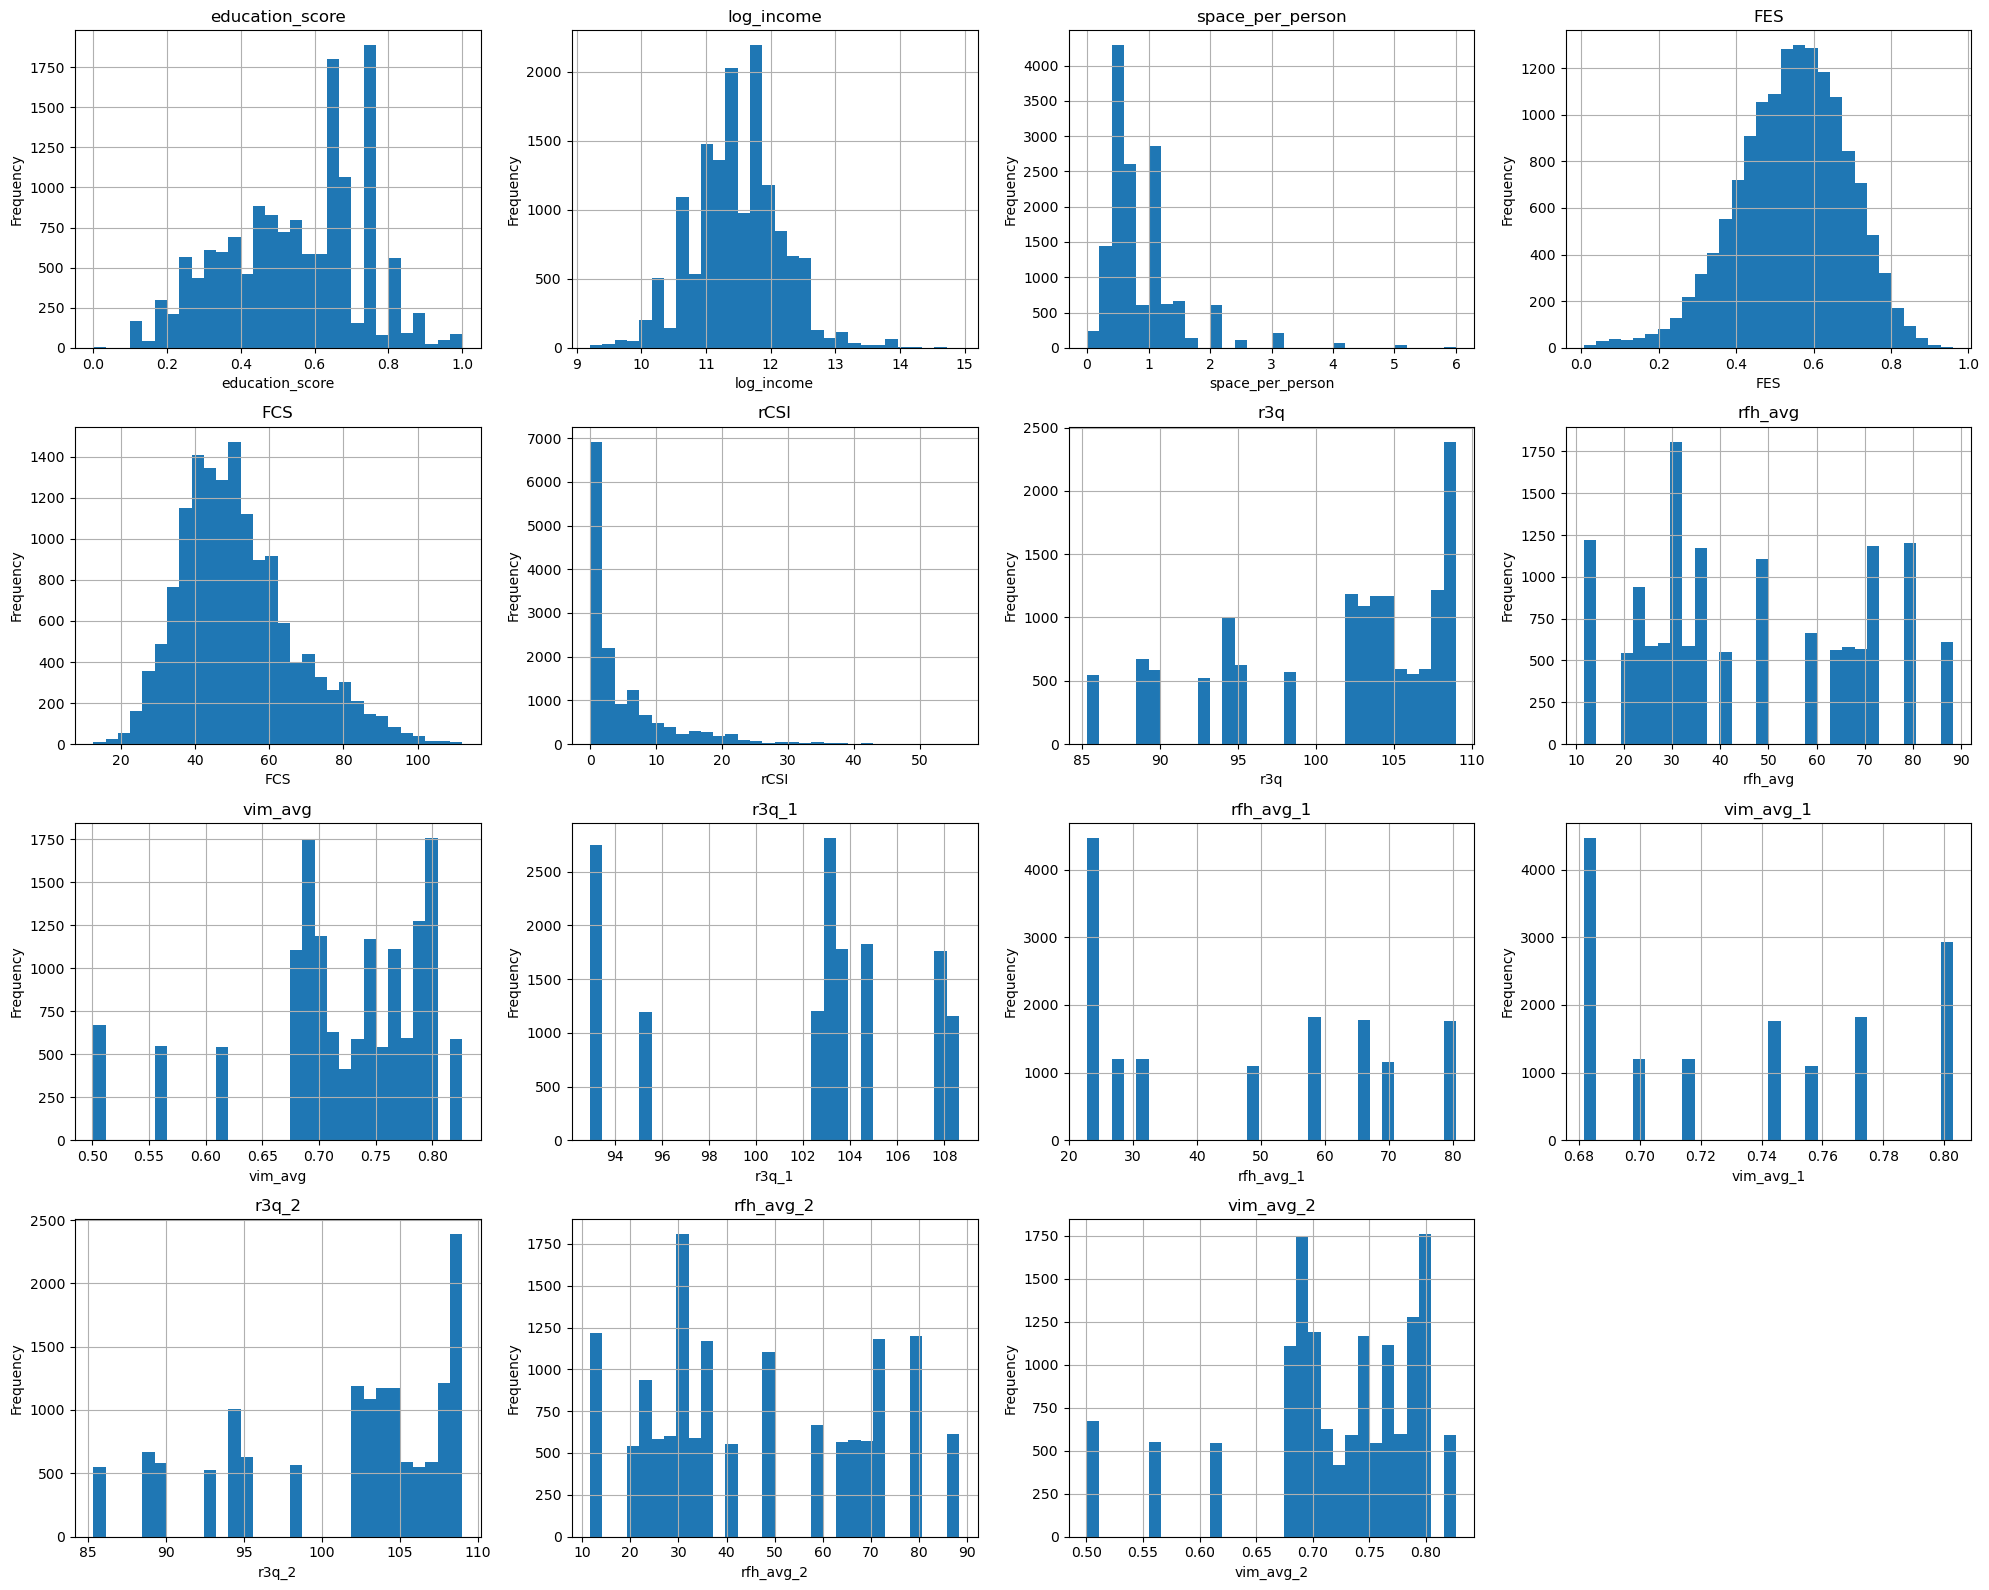

In [18]:
import matplotlib.pyplot as plt

hist_vars = [
    "education_score", "log_income", "space_per_person",
    "FES", "FCS", "rCSI",
    "r3q", "rfh_avg", "vim_avg",
    "r3q_1", "rfh_avg_1", "vim_avg_1",
    "r3q_2", "rfh_avg_2", "vim_avg_2",
]

hist_vars = [c for c in hist_vars if c in df_final.columns]

n_cols = 4
n_rows = int(np.ceil(len(hist_vars) / n_cols)) if hist_vars else 0

if n_rows > 0:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for ax, col in zip(axes, hist_vars):
        s = pd.to_numeric(df_final[col], errors="coerce").dropna()
        ax.axis("on")
        s.hist(bins=30, ax=ax)
        ax.set_title(col)
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()
else:
    print("No histogram variables available.")
